# 公司变量的 PEID 因果超图

本 notebook 复现公司财务变量的单尺度 PEID 分析。核心计算保留在 `scripts/company_ce/peid_causal_hypergraph.py` 中，这里只暴露主要参数，便于手动调节。

## 0. 因果问题与识别边界

本实验的因果问题是：在公司年度面板中，时刻 `t` 的离散增长状态对时刻 `t+1` 的变量状态包含多少 PEID/EI 意义下的有效信息？人口总体是可构造连续年度转移样本的公司-年份观测，处理/来源变量是 `VARIABLES` 中各变量在 `t` 的离散状态，结果变量是同一变量集合在 `t+1` 的离散状态。

理论依据采用 Yang 等（2026）《Partial Effective Information Decomposition for Synergistic Causality》：PEID 在最大熵干预语义下，将多个来源变量对目标变量的有效信息分解为单变量贡献与协同贡献，并允许用有向边和超边表示协同因果结构。因此，本 notebook 的“因果图”是 PEID/EI 意义下的跨期有效信息图。

识别边界需要明确：这不是干预效应估计，也不是 DoWhy/SCM 后门识别后的平均处理效应。当前数据是观察性公司财务面板，潜在混杂包括行业、宏观周期、公司年龄、治理结构、融资约束、并购事件和会计制度差异等。时间顺序 `t -> t+1` 排除了同一时间片内的反向边，但不能单独排除所有未观测混杂。因此，结论应写成“候选跨期机制”“PEID 有效信息边”或“协同信息结构”，而不是现实经营干预的确定因果效应。


## 1. 参数

编辑此单元可以调整变量集合、离散化粒度、零分布重复次数、样本支持阈值和绘图的 Top-K 数量。主实验使用通胀调整后的公司金额变量；`emp` 是例外，因为当前数据中没有 `inf_emp`，所以员工数仍使用原始列。将 `RUN_ANALYSIS = False` 时，若缓存配置匹配则复用已有 CSV 并按需重画图；若缓存缺失或配置不一致，则自动重算。`RUN_SENSITIVITY` 控制是否额外运行参数鲁棒性扫描。

### 可调参数中文说明

| 参数 | 中文说明 | 调参影响 |
|---|---|---|
| `SMOKE` | 是否启用快速烟雾测试模式；由环境变量 `PEID_NOTEBOOK_SMOKE=1` 控制。 | 开启后变量数、零分布重复次数和 Top-K 会变小，用于检查流程，不适合作为正式证据。 |
| `VARIABLES` | 纳入 PEID 分析的公司变量集合；正式主实验为 `inf_at`, `inf_revt`, `emp`, `inf_lt`, `inf_ch`, `inf_ni`, `inf_cogs`。 | 金额变量使用去通胀后的 `inf_*`，减少价格水平变化对跨期增长状态的干扰；变量越多，联合状态支持度会下降。 |
| `BINS` | 连续增长率离散化的分箱数。 | 值越大，状态更细；但每个状态的样本数更少，结果更依赖支持度阈值。 |
| `MAX_SOURCE_ORDER` | PEID 协同超边允许的最大源集合阶数。 | `2` 表示只看二元协同；提高到 `3` 会搜索三变量联合来源，计算量和稀疏风险明显增加。 |
| `ALPHA` | 条件概率估计中的 Dirichlet/Laplace 平滑强度。 | 值越大，低频状态被更强平滑；可降低稀疏噪声，但会压低极端转移差异。 |
| `MIN_SOURCE_COUNT` | 单个源状态进入 EI 估计所需的最小样本数。 | 提高后结果更稳健，但会丢弃低支持状态；降低后可保留稀有状态，但噪声更大。 |
| `MIN_TOTAL_COUNT` | 完整跨期样本的最低数量要求。 | 低于该阈值时停止估计，避免在过小样本上解释因果边。 |
| `NULL_REPS` | 每种零分布随机置换的重复次数。 | 正式比较时应提高到 100 或更多；低值主要用于快速迭代。 |
| `TOP_K` | 图和摘要中展示的 Top 边数量。 | Top-K 仅为摘要视图，不用于原生结果筛选；原生结果保留全量边。 |
| `RANDOM_SEED` | 零分布随机置换的随机种子。 | 固定后便于复现；敏感性分析可另行检查不同 seed。 |
| `YEAR_START` | 样本起始年份；`None` 表示不限制。 | 可用于时期窗口稳健性分析。 |
| `YEAR_END` | 样本结束年份；`None` 表示不限制。 | 可与 `YEAR_START` 配合做时期截面或稳健性分析。 |
| `WINSOR_LOWER` | 对非正值较多变量使用 signed relative change 时的下侧缩尾分位数。 | 提高会更强地截断负向极端值；默认只做轻度缩尾。 |
| `WINSOR_UPPER` | 对 signed relative change 的上侧缩尾分位数。 | 降低会更强地截断正向极端值；需与下侧缩尾保持一致解释。 |
| `RUN_ANALYSIS` | 是否重新运行完整 PEID 分析。 | `True` 会重新计算 CSV 和图；`False` 会先检查缓存配置，匹配时复用，不匹配时重算。 |
| `REUSE_CACHE_WHEN_NOT_RUNNING` | 当不重新运行时，是否允许复用已有 CSV 缓存。 | 通常保持 `True`；缓存会按关键实验配置校验，避免误用旧变量结果。 |
| `RUN_SENSITIVITY` | 是否运行参数鲁棒性扫描。 | 默认关闭；开启后会按下方网格运行多个独立缓存目录。 |
| `SENSITIVITY_BINS_VALUES` | `BINS` 的敏感性扫描取值。 | 默认 `(3, 4, 5, 6)`，重点检查离散化粒度是否改变边排序和协同符号。 |
| `SENSITIVITY_MIN_SOURCE_COUNT_VALUES` | `MIN_SOURCE_COUNT` 的扫描取值。 | 检查低支持状态过滤强度对 EI 与 synergy_raw 的影响。 |
| `SENSITIVITY_ALPHA_VALUES` | `ALPHA` 的扫描取值。 | 检查平滑强度对稀疏条件转移概率的影响。 |
| `SENSITIVITY_WINSOR_PAIRS` | signed relative change 的上下缩尾分位数组合。 | 检查极端增长值处理是否改变主要结论。 |
| `SENSITIVITY_YEAR_WINDOWS` | 年份窗口扫描设置。 | 默认 full/early/late，用于检查时期稳定性。 |
| `INPUT_PATH` | 输入公司年度数据 CSV 的路径。 | 更换数据源时需要同步检查变量名和年份字段。 |
| `OUTPUT_DIR` | 结果 CSV 的输出目录。 | 正式实验继续写入 `results/company_ce/csv/peid`；敏感性扫描写入独立目录避免覆盖。 |
| `FIGURE_DIR` | 图文件输出目录。 | notebook 下方展示的 PNG 也从这里读取；脚本同时导出 PDF 便于论文排版。 |


In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import Image, display

# 路径设置：无论从仓库根目录还是 notebook 目录启动，都能定位项目根目录。
REPO_CWD = Path.cwd().resolve()
candidates = [REPO_CWD, *REPO_CWD.parents]
PROJECT_ROOT = next(path for path in candidates if (path / "AGENTS.md").exists() and (path / "data" / "inf_compustat_anual_US_filter_feas.csv").exists())

SRC_DIR = PROJECT_ROOT / "scripts" / "company_ce"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from peid_causal_hypergraph import PeidConfig, plot_outputs, run_peid_analysis
from peid_sensitivity import SensitivityConfig, run_sensitivity_analysis
from plot_peid_robustness_graphs import (
    configure_style as configure_robustness_graph_style,
    plot_pairwise_grid,
    plot_pairwise_heatmap_grid,
    plot_synergy_grid,
    plot_synergy_heatmap_grid,
)

# `SMOKE`：快速烟雾测试开关；设置环境变量 PEID_NOTEBOOK_SMOKE=1 时启用。
SMOKE = os.getenv("PEID_NOTEBOOK_SMOKE") == "1"

# `VARIABLES`：主实验使用通胀调整后的金额变量；emp 因无 inf_emp 保留原始列。
MAIN_VARIABLES = ["inf_at", "inf_revt", "emp", "inf_lt", "inf_ch", "inf_ni", "inf_cogs"]
SMOKE_VARIABLES = ["inf_at", "inf_revt", "emp"]
VARIABLES = SMOKE_VARIABLES if SMOKE else MAIN_VARIABLES
# `BINS`：增长率离散状态数；默认五分位提供更细的状态划分。
BINS = 5
# `MAX_SOURCE_ORDER`：协同超边的最大源集合阶数；默认只估计二元协同，避免状态空间过稀。
MAX_SOURCE_ORDER = 2
# `ALPHA`：条件转移概率的平滑强度；用于减少低频状态导致的零概率问题。
ALPHA = 0.5
# `MIN_SOURCE_COUNT`：每个源状态的最小样本支持；过低会放大稀疏噪声。
MIN_SOURCE_COUNT = 10 if SMOKE else 20
# `MIN_TOTAL_COUNT`：完整跨期样本的最低数量要求；样本不足时停止估计。
MIN_TOTAL_COUNT = 100
# `NULL_REPS`：每种零分布置换重复次数；正式证据建议提高到 100 或更多。
NULL_REPS = 2 if SMOKE else 20
# `TOP_K`：图和结果表展示的最强边数量；图过密时优先减小该值。
TOP_K = 5 if SMOKE else 12
# `RANDOM_SEED`：零分布随机置换种子；固定后便于复现实验。
RANDOM_SEED = 42
# `YEAR_START` / `YEAR_END`：样本年份窗口；None 表示使用全部年份。
YEAR_START = None
YEAR_END = None
# `WINSOR_LOWER` / `WINSOR_UPPER`：signed relative change 的上下缩尾分位数。
WINSOR_LOWER = 0.01
WINSOR_UPPER = 0.99
# `RUN_ANALYSIS`：是否重新运行完整计算；False 时会先校验并复用匹配缓存。
RUN_ANALYSIS = True
# `REUSE_CACHE_WHEN_NOT_RUNNING`：不重跑时是否允许读取已有 CSV 缓存。
REUSE_CACHE_WHEN_NOT_RUNNING = True
# `RUN_SENSITIVITY`：是否运行参数鲁棒性扫描；正式运行会生成多个独立缓存目录。
RUN_SENSITIVITY = False
SENSITIVITY_BINS_VALUES = (3, 4, 5, 6)
SENSITIVITY_MIN_SOURCE_COUNT_VALUES = (10, 20, 50)
SENSITIVITY_ALPHA_VALUES = (0.1, 0.5, 1.0)
SENSITIVITY_WINSOR_PAIRS = ((0.005, 0.995), (0.01, 0.99), (0.025, 0.975))
SENSITIVITY_YEAR_WINDOWS = (("full", None, None), ("early", None, 2000), ("late", 2001, None))

# `INPUT_PATH`：输入公司年度数据；`OUTPUT_DIR`：CSV 输出；`FIGURE_DIR`：PNG/PDF 图输出。
INPUT_PATH = PROJECT_ROOT / "data" / "inf_compustat_anual_US_filter_feas.csv"
OUTPUT_DIR = PROJECT_ROOT / "results" / "company_ce" / "csv" / ("peid_notebook_smoke" if SMOKE else "peid")
FIGURE_DIR = PROJECT_ROOT / "fig" / "company_ce" / ("peid_notebook_smoke" if SMOKE else "peid")

config = PeidConfig(
    input_path=str(INPUT_PATH),
    output_dir=str(OUTPUT_DIR),
    figure_dir=str(FIGURE_DIR),
    variables=tuple(VARIABLES),
    bins=BINS,
    max_source_order=MAX_SOURCE_ORDER,
    alpha=ALPHA,
    min_source_count=MIN_SOURCE_COUNT,
    min_total_count=MIN_TOTAL_COUNT,
    null_reps=NULL_REPS,
    top_k=TOP_K,
    random_seed=RANDOM_SEED,
    year_start=YEAR_START,
    year_end=YEAR_END,
    winsor_lower=WINSOR_LOWER,
    winsor_upper=WINSOR_UPPER,
)

config


PeidConfig(input_path='/Users/yangmingzhe/Desktop/code/github/EISyn/data/inf_compustat_anual_US_filter_feas.csv', output_dir='/Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid', figure_dir='/Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid', variables=('inf_at', 'inf_revt', 'emp', 'inf_lt', 'inf_ch', 'inf_ni', 'inf_cogs'), bins=5, max_source_order=2, alpha=0.5, min_source_count=20, min_total_count=100, null_reps=20, top_k=12, random_seed=42, year_start=None, year_end=None, winsor_lower=0.01, winsor_upper=0.99)

## 2. 运行或复用分析

这一步会构建离散的公司-年份转移样本，估计成对 EI 和 PEID 协同超边，执行零分布随机置换，写出 CSV 文件，并保存结果图。

In [2]:
# 当 RUN_ANALYSIS=False 时，若缓存配置匹配则复用；缓存缺失或关键配置不一致时会自动重算。
result = run_peid_analysis(
    config,
    skip_figures=False,
    reuse_cache=(not RUN_ANALYSIS and REUSE_CACHE_WHEN_NOT_RUNNING),
)
result


{'output_dir': '/Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid',
 'figure_dir': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid',
 'reused_cache': 'false',
 'cache_reason': 'cache_disabled'}

## 3. 原生结果：全量边表

本节首先查看原生结果：`peid_pairwise_edges.csv` 保留所有单源跨期 EI 边，`peid_synergy_hyperedges.csv` 保留所有协同超边，`peid_native_edges_for_review.csv` 将两类全量边合并成 review 表。这里不按 Top-K 截断；协同结果以 `synergy_raw` 为主。当前实现按源侧条件总相关口径估计协同，因此 `synergy_raw` 本身应为非负；`synergy` 与 `synergy_raw` 同值，只作为兼容绘图和结果读取代码的列保留。


In [3]:
audit = pd.read_csv(OUTPUT_DIR / "peid_variable_audit.csv")
pairwise = pd.read_csv(OUTPUT_DIR / "peid_pairwise_edges.csv")
synergy = pd.read_csv(OUTPUT_DIR / "peid_synergy_hyperedges.csv")
native_edges = pd.read_csv(OUTPUT_DIR / "peid_native_edges_for_review.csv")
top_edges = pd.read_csv(OUTPUT_DIR / "peid_top_edges_for_figures.csv")

print("输出表：", OUTPUT_DIR)
print("图目录：", FIGURE_DIR)
print(f"全量 pairwise 边数：{len(pairwise)}；全量 synergy 超边数：{len(synergy)}")
display(audit)
display(pairwise)
display(synergy[["sources", "target", "source_order", "joint_ei", "single_ei_sum", "synergy_raw", "synergy", "p_value", "source_support", "total_count"]])
display(native_edges)


输出表： /Users/yangmingzhe/Desktop/code/github/EISyn/results/company_ce/csv/peid
图目录： /Users/yangmingzhe/Desktop/code/github/EISyn/fig/company_ce/peid
全量 pairwise 边数：49；全量 synergy 超边数：147


,variable,transform,n_level_rows,n_positive_rows,n_growth_rows,n_firms,growth_mean,growth_std,n_complete_growth_rows,n_complete_transition_pairs,n_complete_transition_firms
0,inf_at,log_growth,500827,499741,461955,35969,0.087400,0.589776,286049,253067,24394
1,inf_revt,log_growth,465630,455920,418222,33318,0.075600,0.554118,286049,253067,24394
2,emp,log_growth,399009,394819,356092,30440,0.041585,0.414691,286049,253067,24394
3,inf_lt,log_growth,478266,477993,440048,35512,0.092290,0.608138,286049,253067,24394
4,inf_ch,log_growth,412439,405386,363589,33155,0.057906,1.222658,286049,253067,24394
5,inf_ni,signed_relative_change,498057,324353,459852,35970,-0.263433,4.144077,286049,253067,24394
6,inf_cogs,log_growth,486220,467041,428233,34277,0.081013,0.601404,286049,253067,24394


,source,target,ei,source_support,total_count,row_sum_error,null_mean,null_std,z_score,p_value
0,inf_ni,inf_ni,0.139564,5,253067,1.110223e-16,0.032155,0.032531,3.301713,0.024390
1,inf_at,inf_revt,0.131216,5,253067,1.110223e-16,0.019120,0.019329,5.799462,0.024390
2,inf_revt,inf_revt,0.124662,5,253067,0.000000e+00,0.036818,0.037243,2.358664,0.024390
3,emp,inf_revt,0.123967,5,253067,1.110223e-16,0.016821,0.016998,6.303641,0.024390
4,inf_at,inf_at,0.121011,5,253067,2.220446e-16,0.037231,0.037664,2.224411,0.024390
5,inf_at,inf_cogs,0.119836,5,253067,1.110223e-16,0.012959,0.013081,8.170521,0.024390
6,emp,inf_cogs,0.113703,5,253067,1.110223e-16,0.011971,0.012081,8.420788,0.024390
7,inf_revt,inf_cogs,0.102410,5,253067,0.000000e+00,0.021191,0.021415,3.792620,0.024390
8,inf_cogs,inf_cogs,0.097855,5,253067,0.000000e+00,0.031693,0.032053,2.064125,0.024390
9,emp,emp,0.097092,5,253067,1.110223e-16,0.034698,0.035101,1.777555,0.024390


,sources,target,source_order,joint_ei,single_ei_sum,synergy_raw,synergy,p_value,source_support,total_count
0,inf_at+inf_lt,inf_at,2,0.148899,0.120638,0.028261,0.028261,0.024390,25,253067
1,inf_at+inf_ni,inf_ni,2,0.164007,0.143734,0.020273,0.020273,0.024390,25,253067
2,inf_at+inf_lt,inf_lt,2,0.090422,0.070297,0.020126,0.020126,0.024390,25,253067
3,inf_revt+inf_cogs,inf_cogs,2,0.109442,0.091013,0.018429,0.018429,0.024390,25,253067
4,inf_at+inf_lt,inf_ni,2,0.069953,0.051689,0.018264,0.018264,0.024390,25,253067
...,...,...,...,...,...,...,...,...,...,...
142,inf_revt+inf_ch,inf_lt,2,0.048023,0.047443,0.000580,0.000580,0.024390,25,253067
143,inf_revt+inf_cogs,inf_ch,2,0.016581,0.012813,0.003768,0.003768,0.146341,25,253067
144,inf_at+emp,inf_ch,2,0.015462,0.014167,0.001296,0.001296,0.195122,25,253067
145,emp+inf_cogs,inf_ch,2,0.011591,0.010612,0.000979,0.000979,0.463415,25,253067


,edge_type,rank,label,source,source_set,target,source_order,value_col,value,value_abs,p_value,null_mean,source_support,total_count,ei,synergy_raw,synergy
0,pairwise,1,inf_ni -> inf_ni,inf_ni,inf_ni,inf_ni,1,ei,0.139564,0.139564,0.024390,0.032155,5,253067,0.139564,NaN,NaN
1,pairwise,2,inf_at -> inf_revt,inf_at,inf_at,inf_revt,1,ei,0.131216,0.131216,0.024390,0.019120,5,253067,0.131216,NaN,NaN
2,pairwise,3,inf_revt -> inf_revt,inf_revt,inf_revt,inf_revt,1,ei,0.124662,0.124662,0.024390,0.036818,5,253067,0.124662,NaN,NaN
3,pairwise,4,emp -> inf_revt,emp,emp,inf_revt,1,ei,0.123967,0.123967,0.024390,0.016821,5,253067,0.123967,NaN,NaN
4,pairwise,5,inf_at -> inf_at,inf_at,inf_at,inf_at,1,ei,0.121011,0.121011,0.024390,0.037231,5,253067,0.121011,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,synergy,143,"{inf_revt, inf_ch} -> inf_lt",inf_revt+inf_ch,inf_revt+inf_ch,inf_lt,2,synergy_raw,0.000580,0.000580,0.024390,0.000264,25,253067,NaN,0.000580,0.000580
192,synergy,144,"{inf_revt, inf_cogs} -> inf_ch",inf_revt+inf_cogs,inf_revt+inf_cogs,inf_ch,2,synergy_raw,0.003768,0.003768,0.146341,0.002051,25,253067,NaN,0.003768,0.003768
193,synergy,145,"{inf_at, emp} -> inf_ch",inf_at+emp,inf_at+emp,inf_ch,2,synergy_raw,0.001296,0.001296,0.195122,0.000743,25,253067,NaN,0.001296,0.001296
194,synergy,146,"{emp, inf_cogs} -> inf_ch",emp+inf_cogs,emp+inf_cogs,inf_ch,2,synergy_raw,0.000979,0.000979,0.463415,0.000699,25,253067,NaN,0.000979,0.000979


## 4. 原生结果图：pairwise EI 与 synergy_raw

pairwise EI 热图展示所有变量对的跨期有效信息，不做边筛选。synergy_raw 图展示所有联合来源集合对目标变量的原始源侧协同值；该值按条件总相关口径估计，不再需要正部截断。


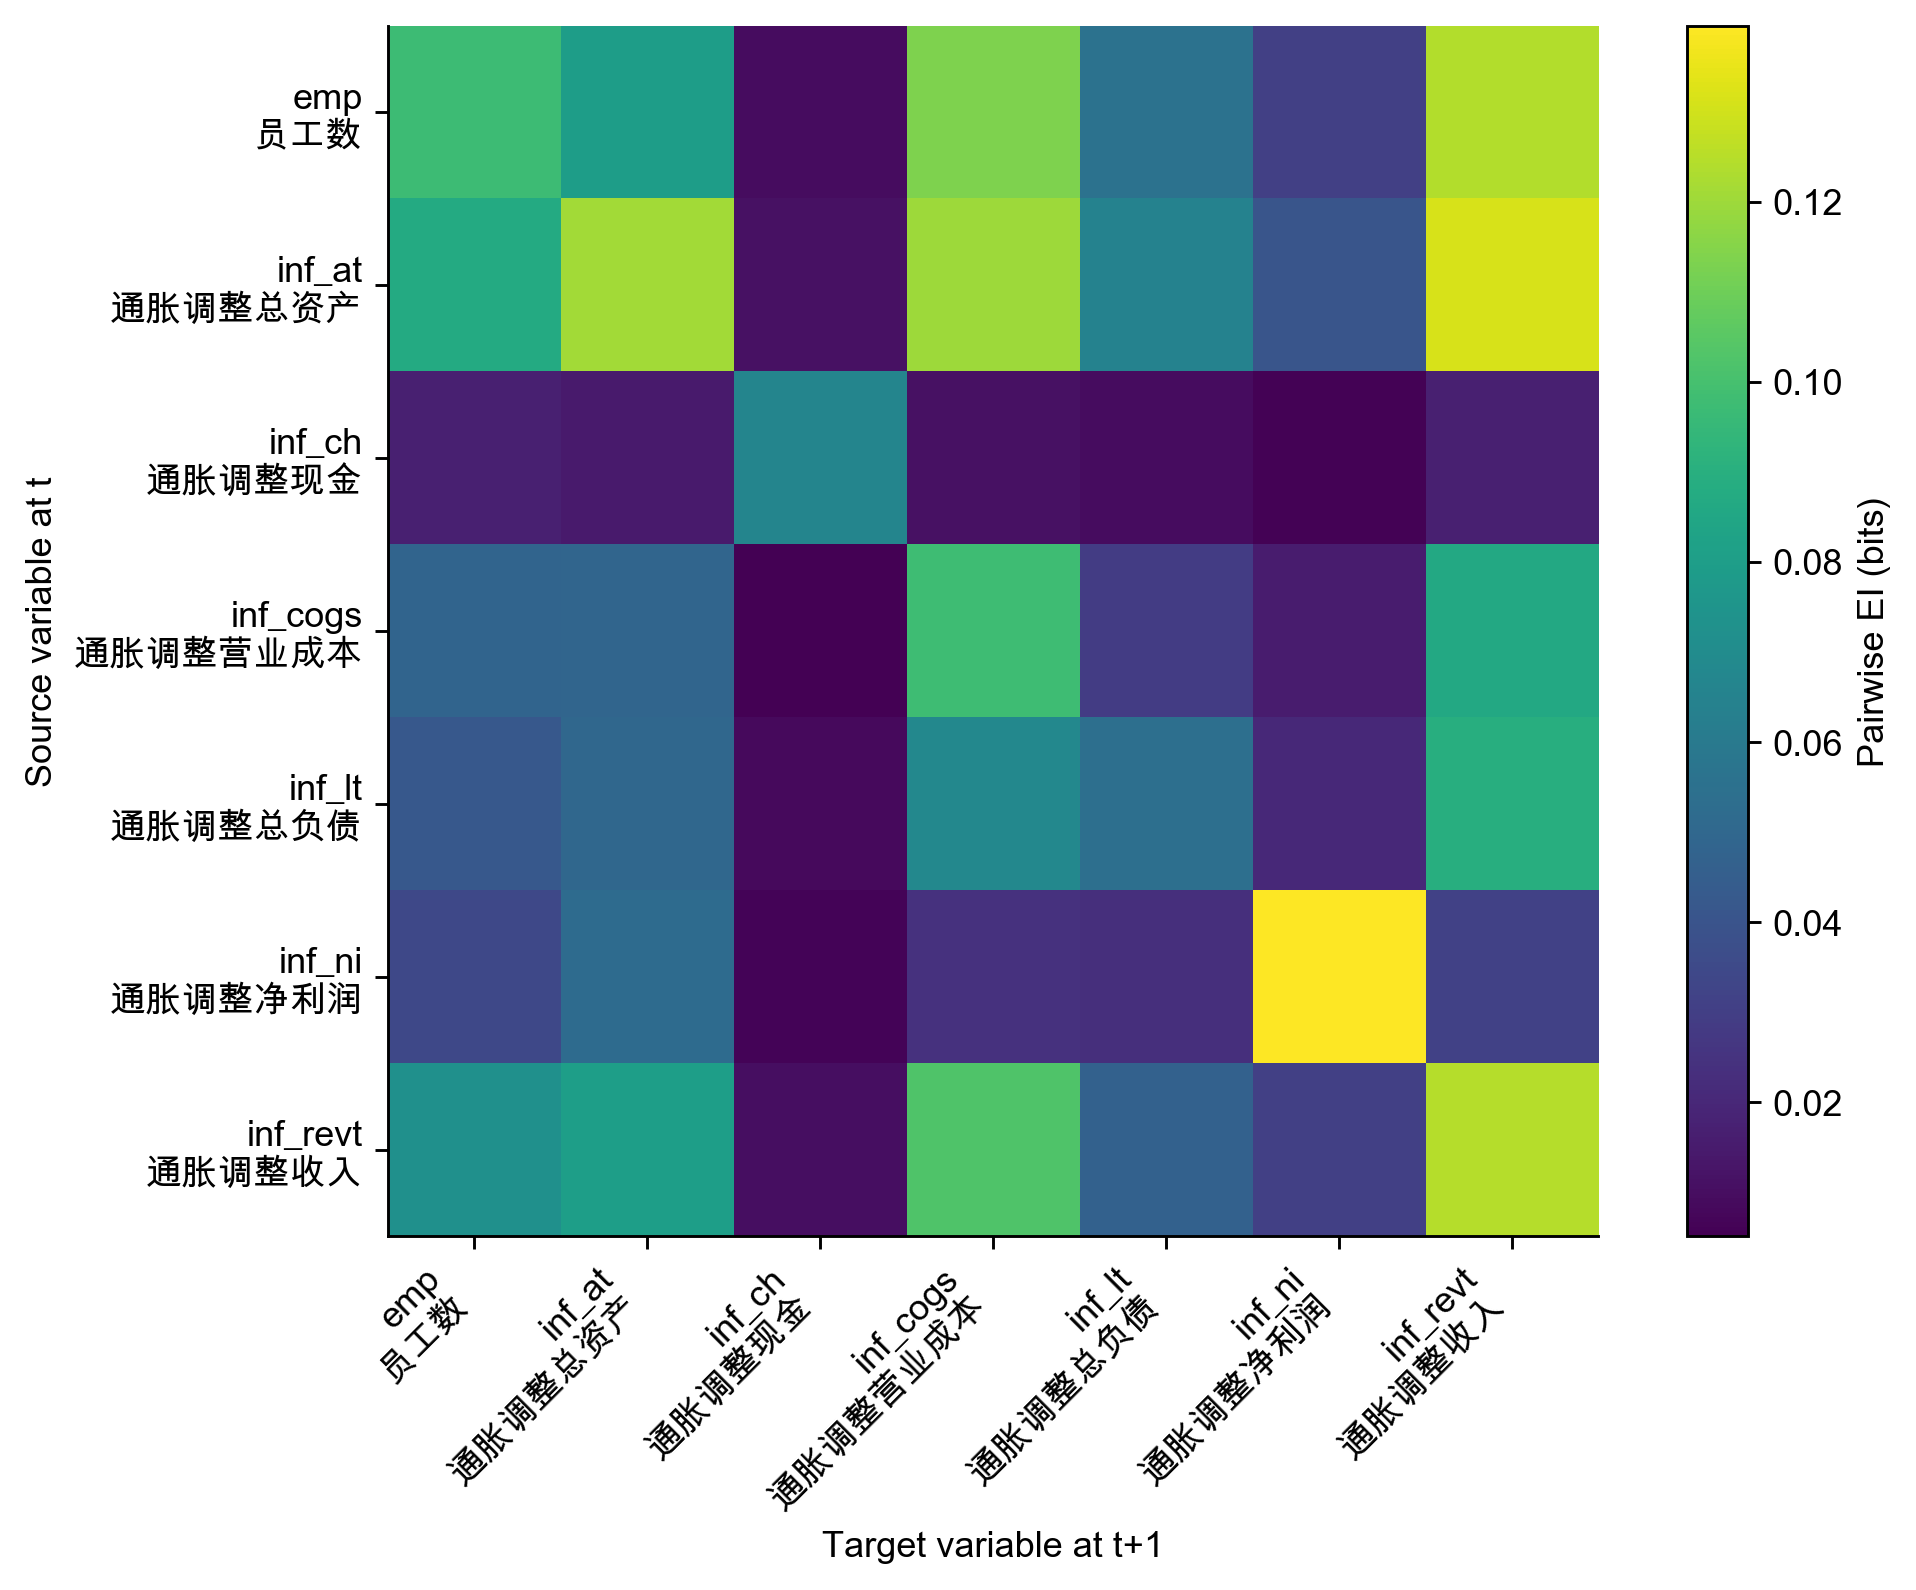

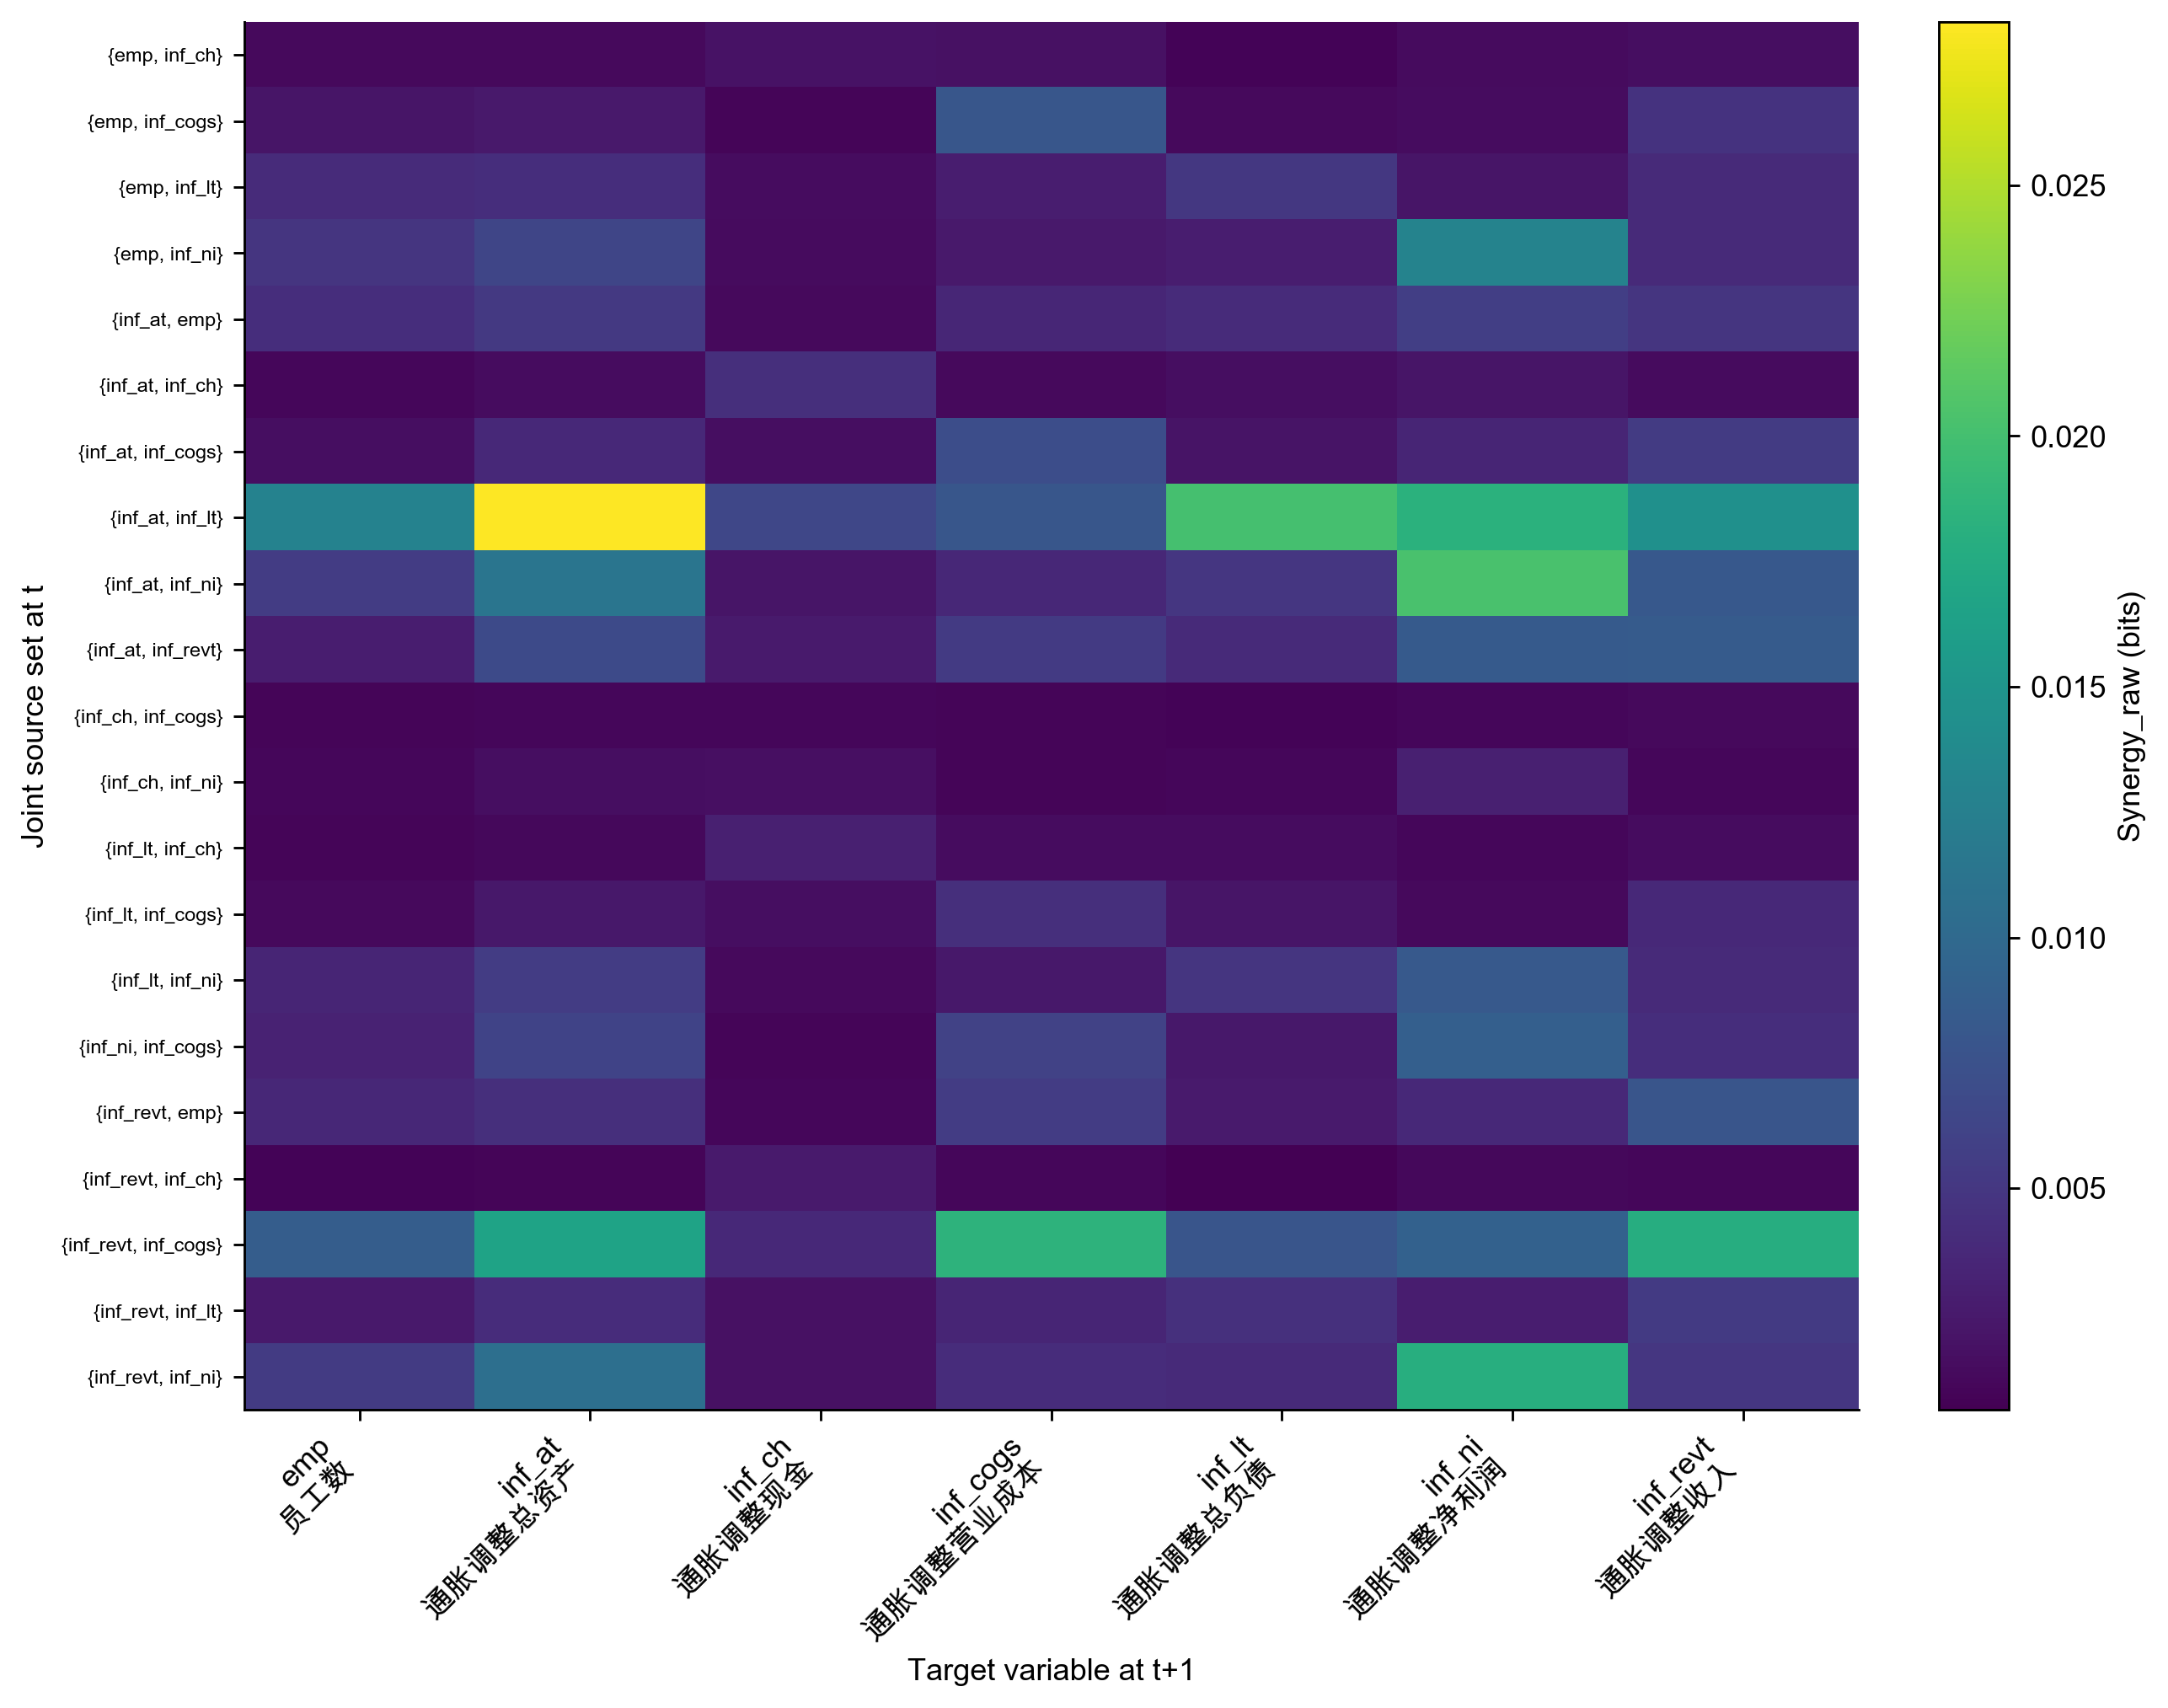

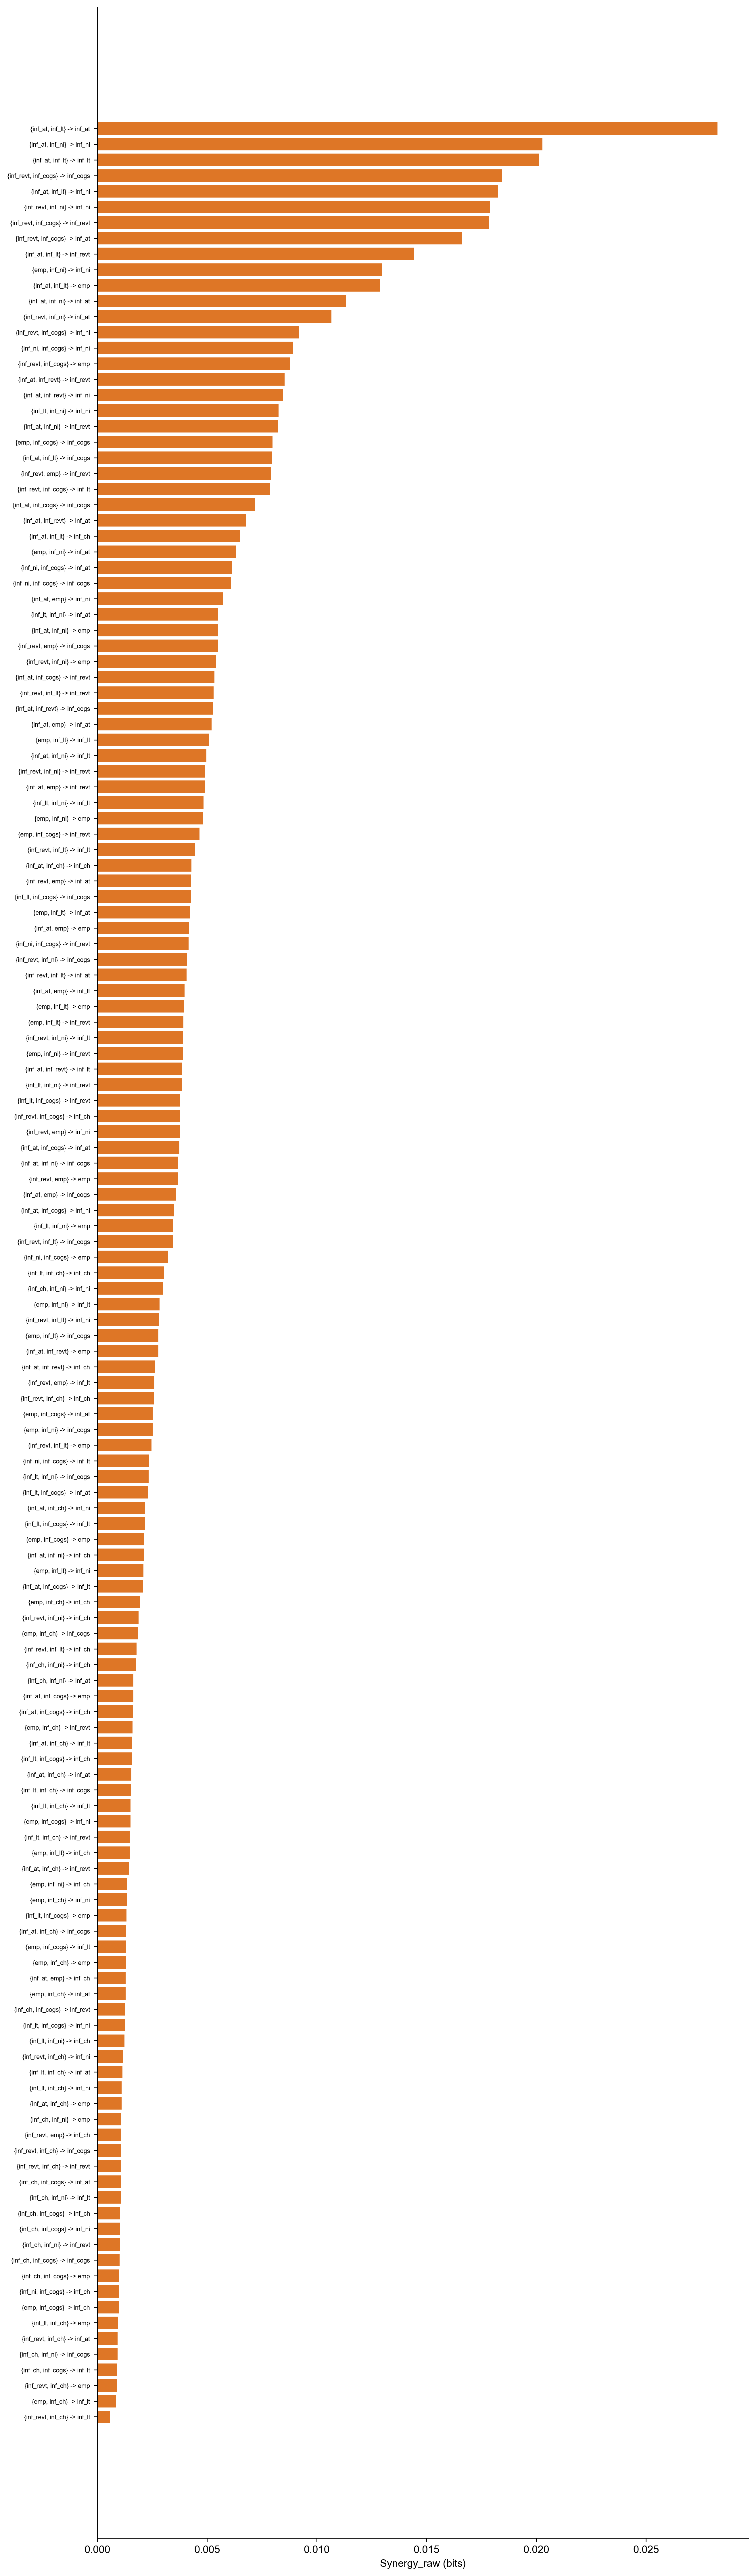

In [4]:
display(Image(filename=str(FIGURE_DIR / "peid_pairwise_ei_heatmap.png")))
display(Image(filename=str(FIGURE_DIR / "peid_synergy_raw_heatmap.png")))
display(Image(filename=str(FIGURE_DIR / "peid_synergy_raw_ranked.png")))


## 5. Top-K 摘要视图：因果证据汇总

从这里开始的 Top-K 图只用于摘要和人工阅读，Top-K 仅为摘要视图，不代表原生结果被截断。正式解释时应先引用上方全量边表和 `synergy_raw`，再用本节图说明最强候选边。


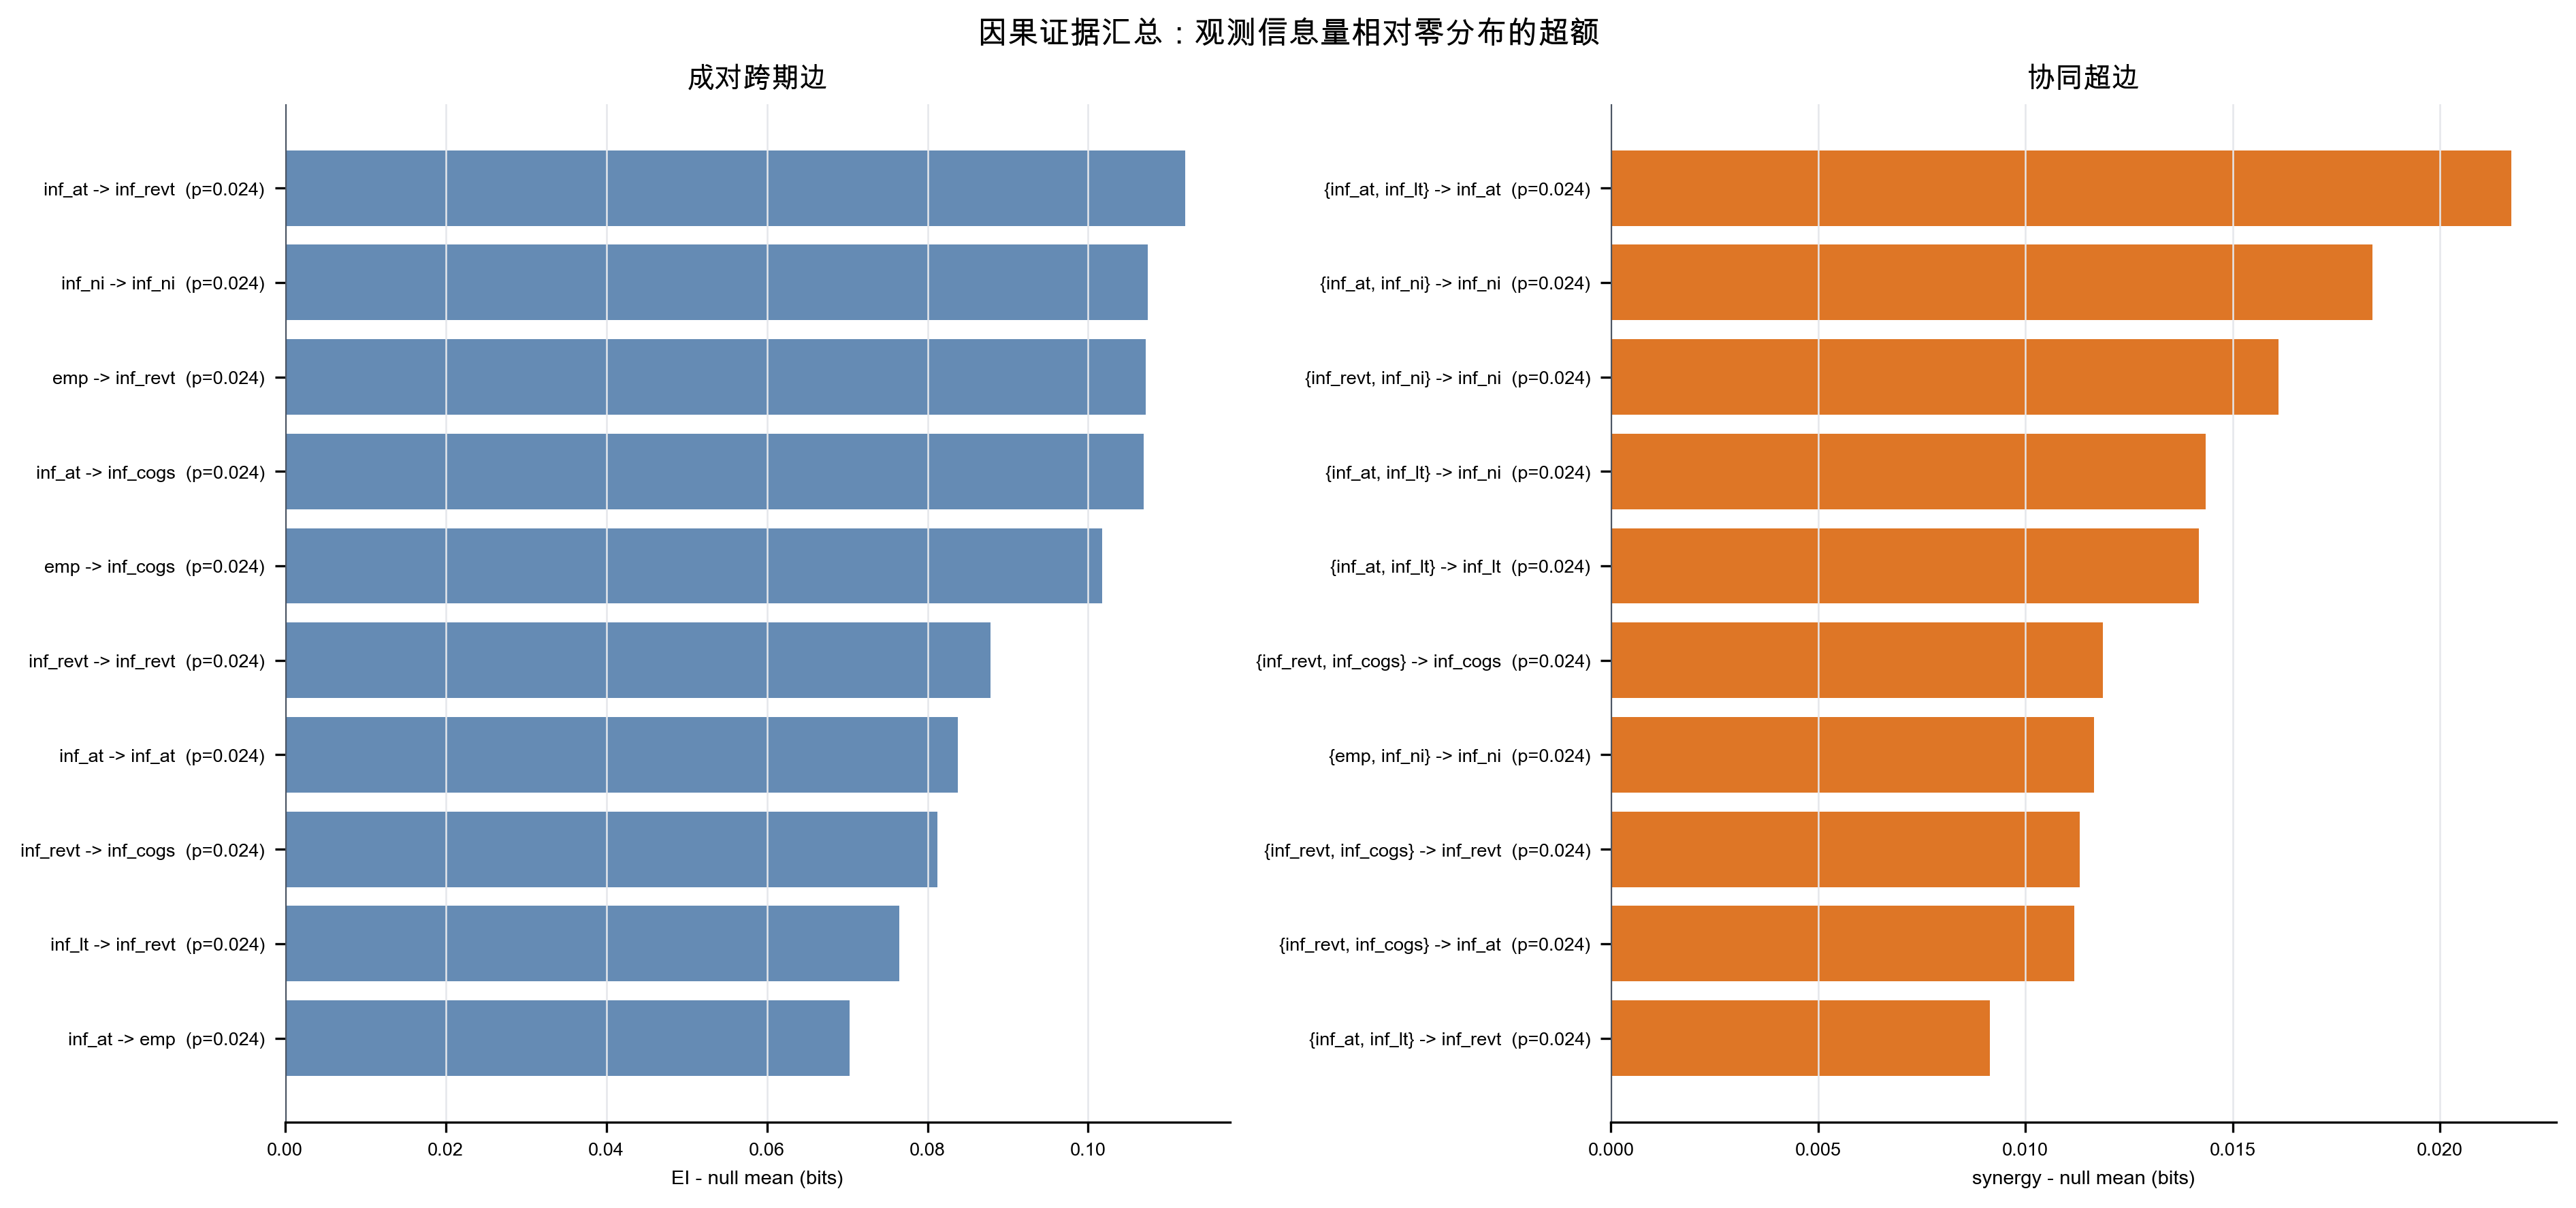

In [5]:
display(Image(filename=str(FIGURE_DIR / "peid_causal_evidence_summary.png")))


### 证据汇总结果分析

证据汇总图用于比较观测到的成对 EI 或协同强度相对零分布均值的超额。重新运行主实验后，优先查看 `inf_at`, `inf_revt`, `emp`, `inf_lt`, `inf_ch`, `inf_ni`, `inf_cogs` 之间哪些边同时满足较高观测值、较大超额和较低经验 p 值。

解释时应区分两类结果：成对边表示单个来源变量在 PEID/EI 意义下对下一期目标状态的有效信息；协同超边表示多个来源联合后超过单变量 EI 加总的额外信息。若 `RUN_ANALYSIS=False` 且缓存被复用，本节解释对应缓存中的配置；可先检查上方 `result["cache_reason"]` 和 `peid_run_config.json`。

## 6. Top-K 成对因果图

这张图把时刻 `t` 的源变量放在左侧，把时刻 `t+1` 的目标变量放在右侧，仅展示按零分布排名筛选后的 Top-K 成对 EI 边。它表示跨期机制信息关系，而不是同期观测相关关系；未显示的边仍保留在原生全量边表中。


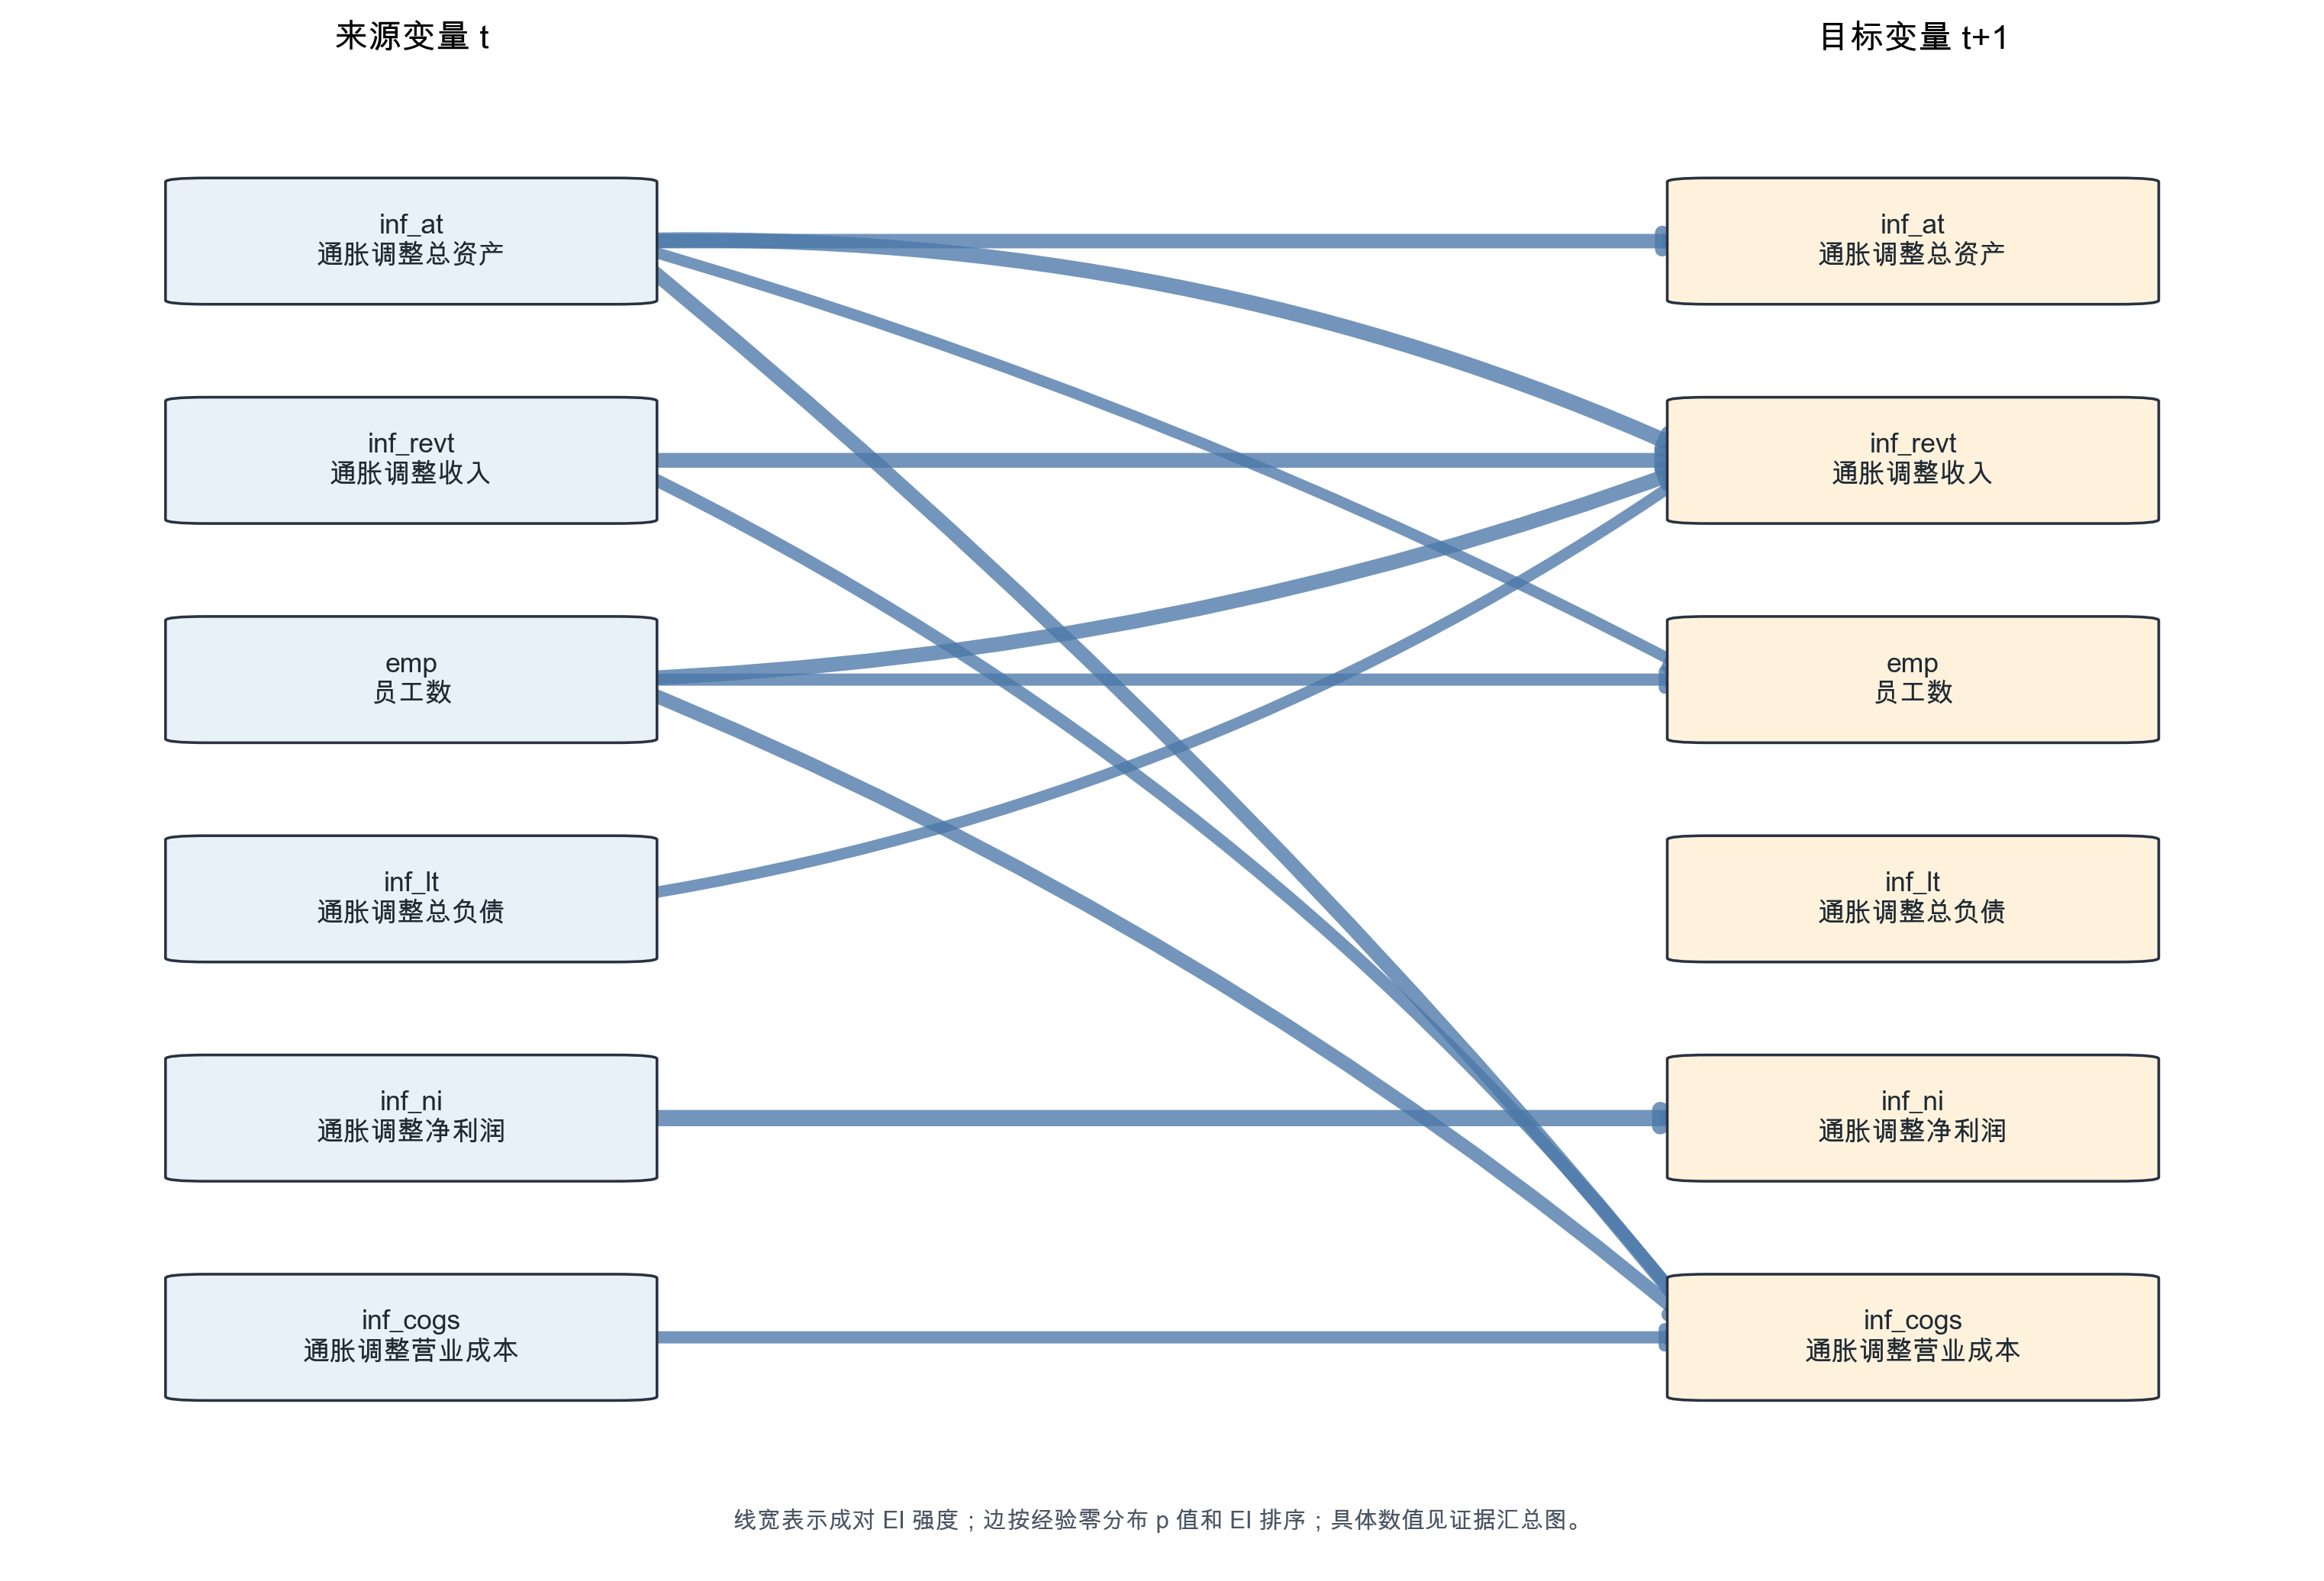

In [6]:
display(Image(filename=str(FIGURE_DIR / "peid_top_pairwise_graph.png")))

### 因果图结果分析

成对因果图展示通胀调整变量集合中的 Top-K 单源跨期信息边。对于金额变量，应优先使用 `inf_*` 名称解释结果，例如 `inf_at` 表示通胀调整后的总资产，而不是原始名义总资产；`emp` 是员工数原始列，因为数据中没有 `inf_emp`。

图中的边应表述为“候选跨期机制边”或“PEID/EI 意义下的有效信息边”。它们不等同于准实验或政策干预中的平均处理效应；正式论文中应结合更高 `NULL_REPS`、不同 `BINS` 和年份窗口检查稳定性。

## 7. Top-K PEID 协同超图

每个源集合节点（例如 `{inf_at, inf_revt}`）指向某个目标变量。该图使用 `synergy` 来画线宽；当前 `synergy` 与 `synergy_raw` 同值，因此不再包含正部截断。原生解释以全量表中的 `synergy_raw` 为准。


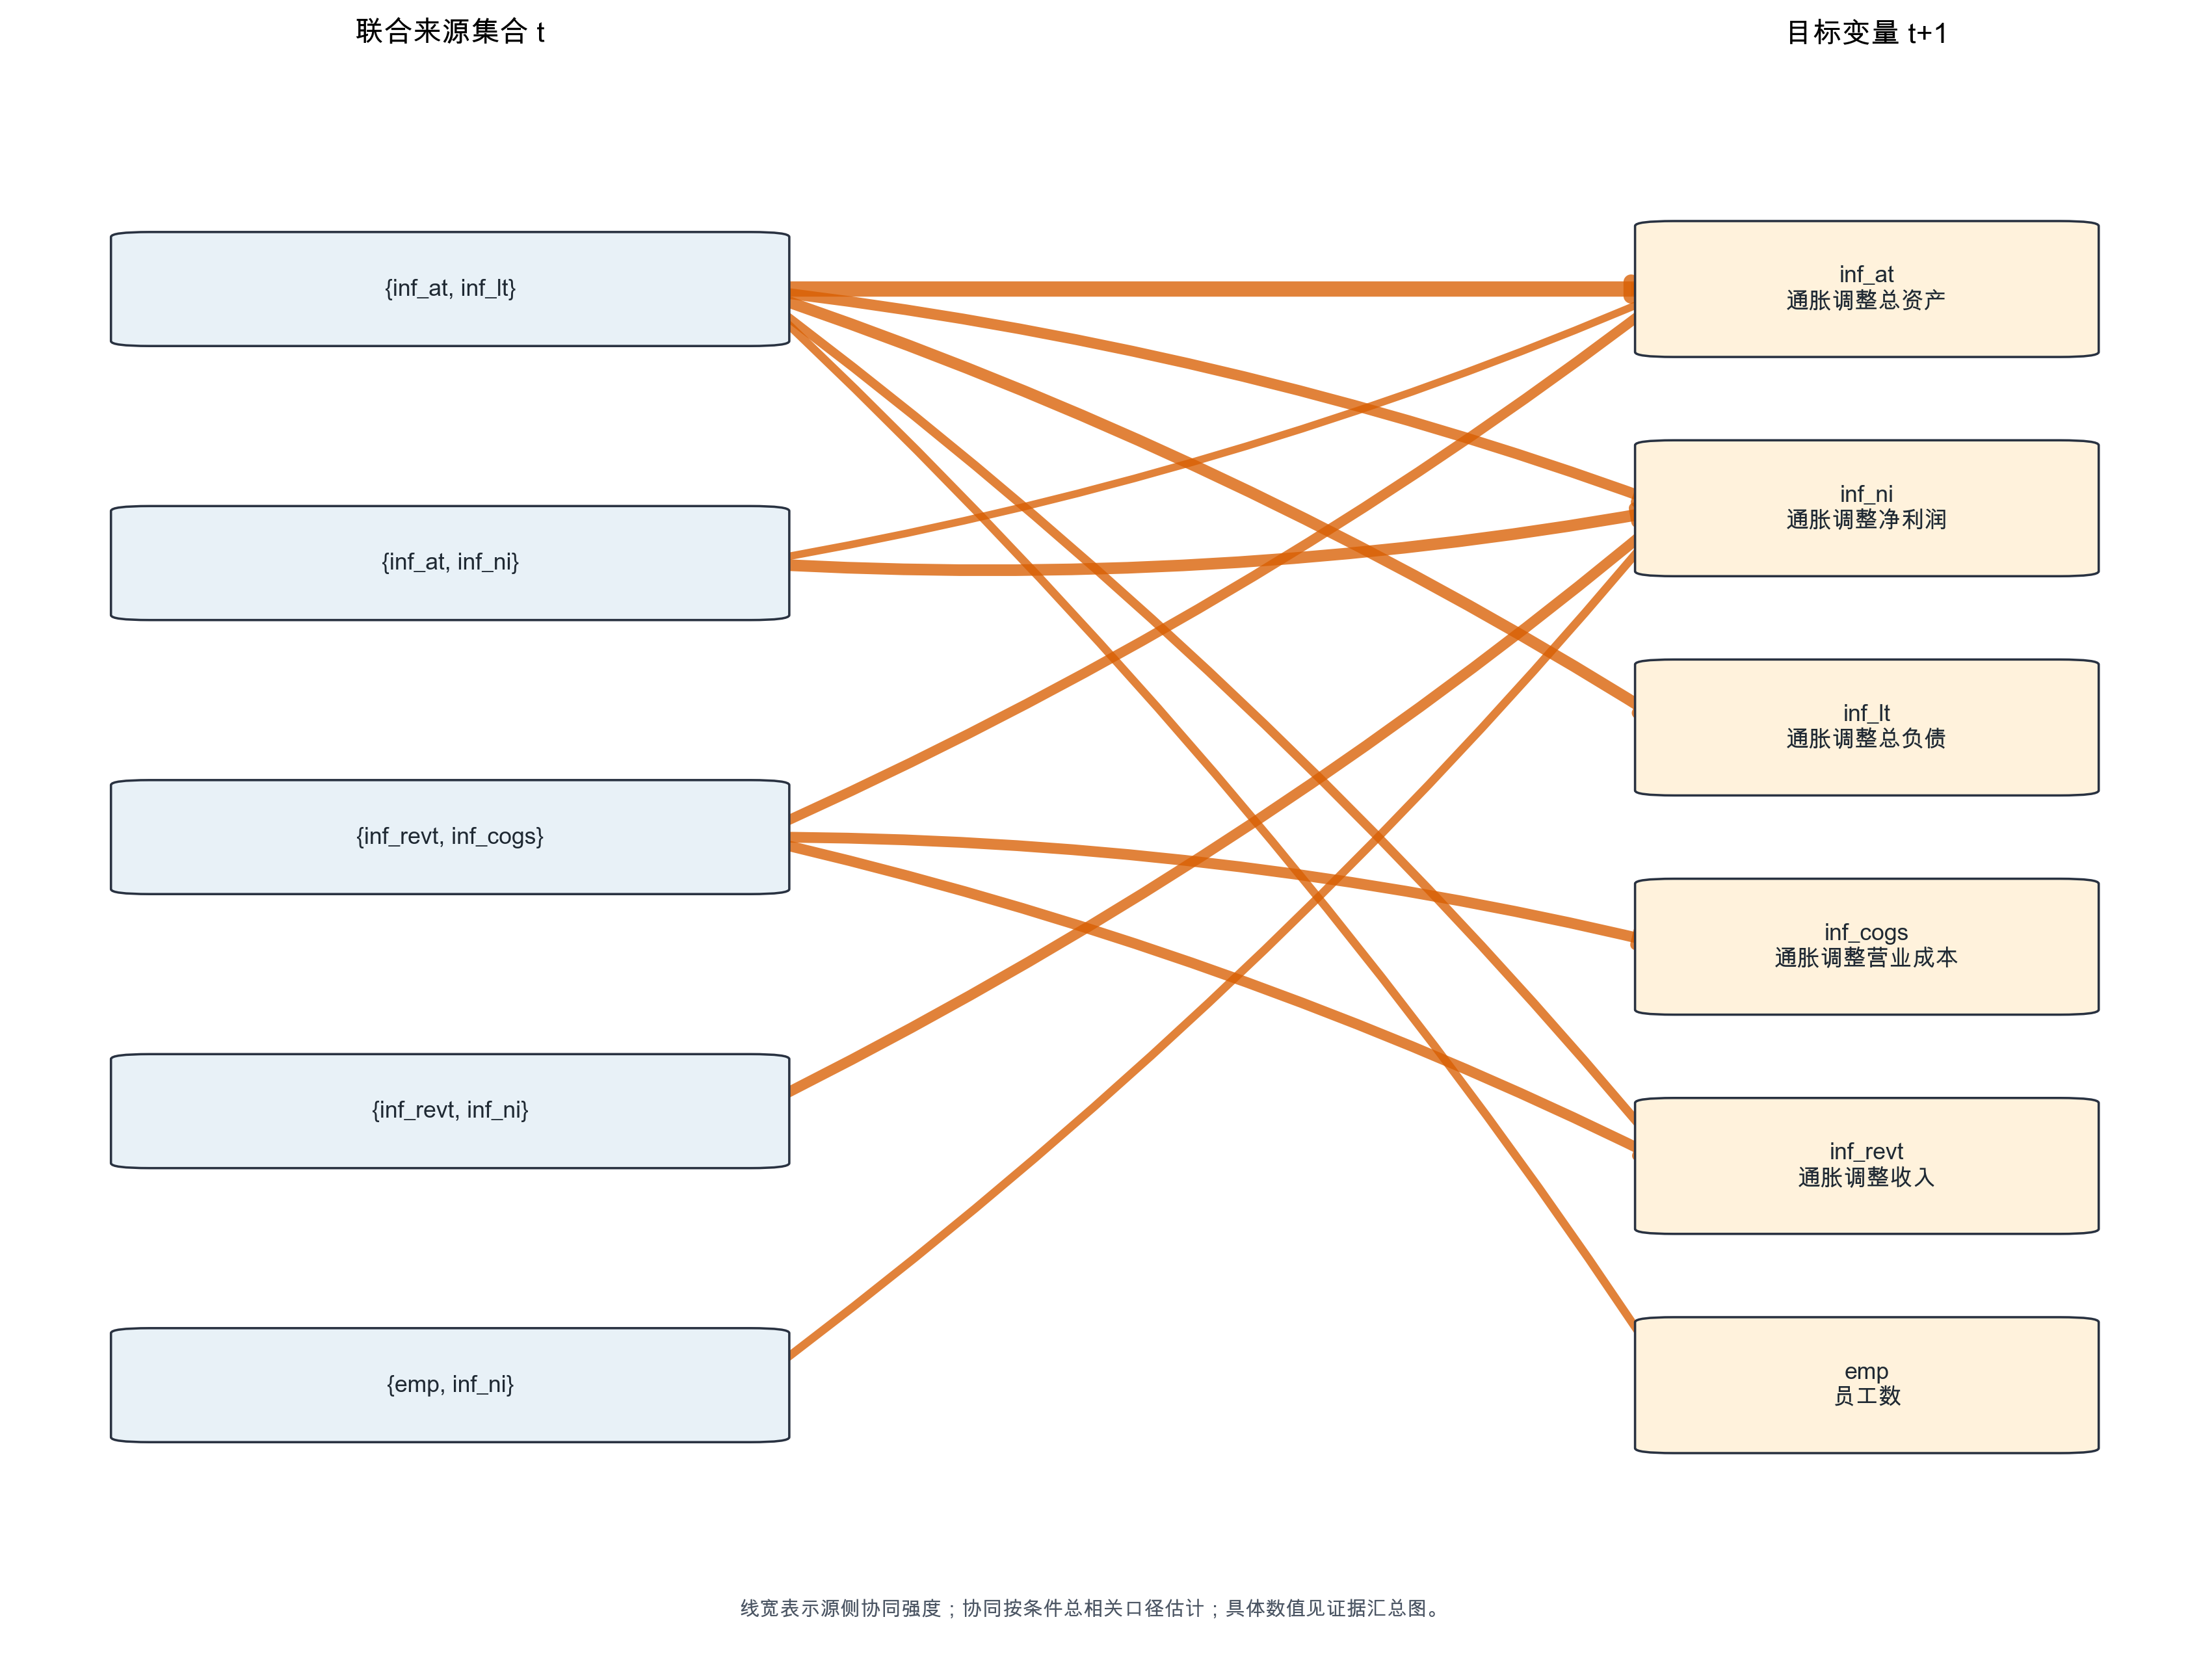

In [7]:
display(Image(filename=str(FIGURE_DIR / "peid_top_synergy_hypergraph.png")))

### 协同超图结果分析

协同超图展示多个来源变量联合预测下一期目标状态时，相对单变量 EI 加总额外提供的信息。重新运行后，应关注协同边是否稳定地出现在通胀调整资产、收入、负债、现金、净利润、营业成本与员工数之间，而不是沿用旧 raw-variable 实验中的具体边名。

协同值通常会小于成对 EI，因此解释重点应放在“联合来源是否提供单变量边无法覆盖的补充机制”。如果要把协同超边作为核心发现，需要提高 `NULL_REPS` 并比较不同变量集合和分箱设置下的排序稳定性。

## 8. 零分布比较

这张图比较 Top-K 摘要边的观测 EI/协同值与零分布均值。若要将 p 值或 z 分数作为正式证据，请先把 `NULL_REPS` 提高到 100 或更多。


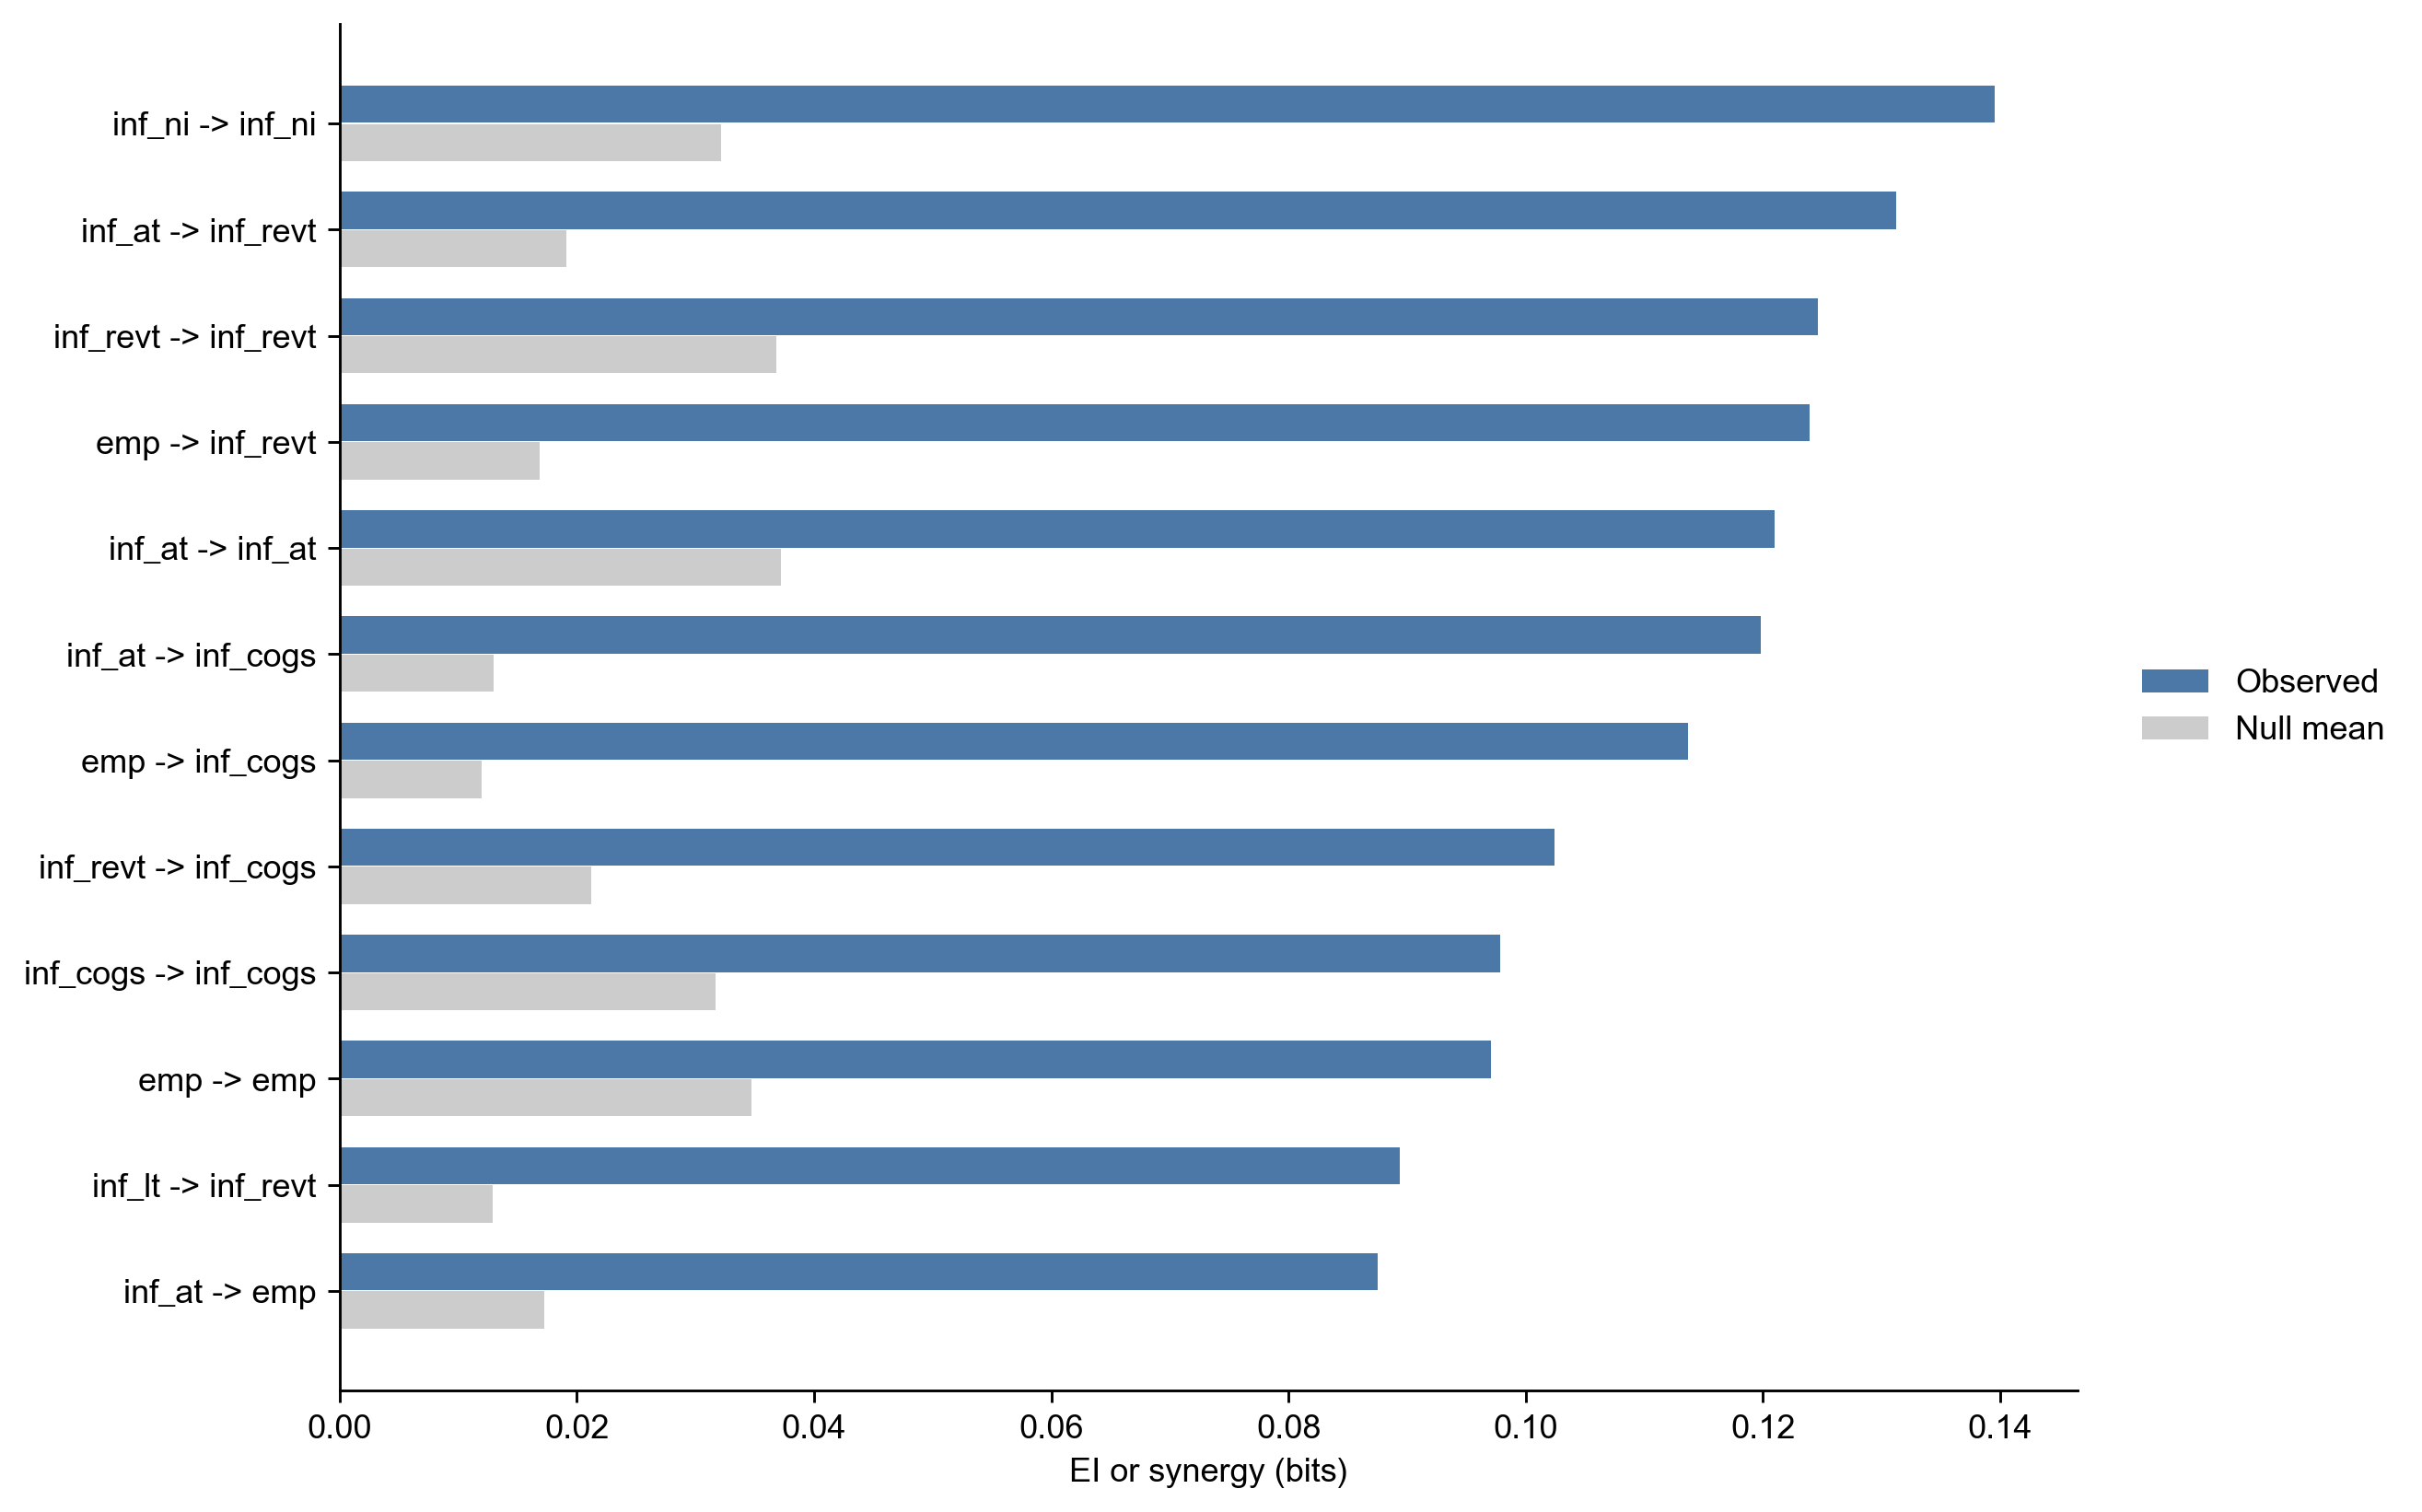

In [8]:
display(Image(filename=str(FIGURE_DIR / "peid_null_comparison.png")))

## 9. 时期稳定性

时期稳定性图把 Top-K 成对边分为 early/late 两段重估。更完整的参数鲁棒性检验见下一节，它会对 BINS、MIN_SOURCE_COUNT、ALPHA、WINSOR 和年份窗口做 one-factor-at-a-time 扫描。


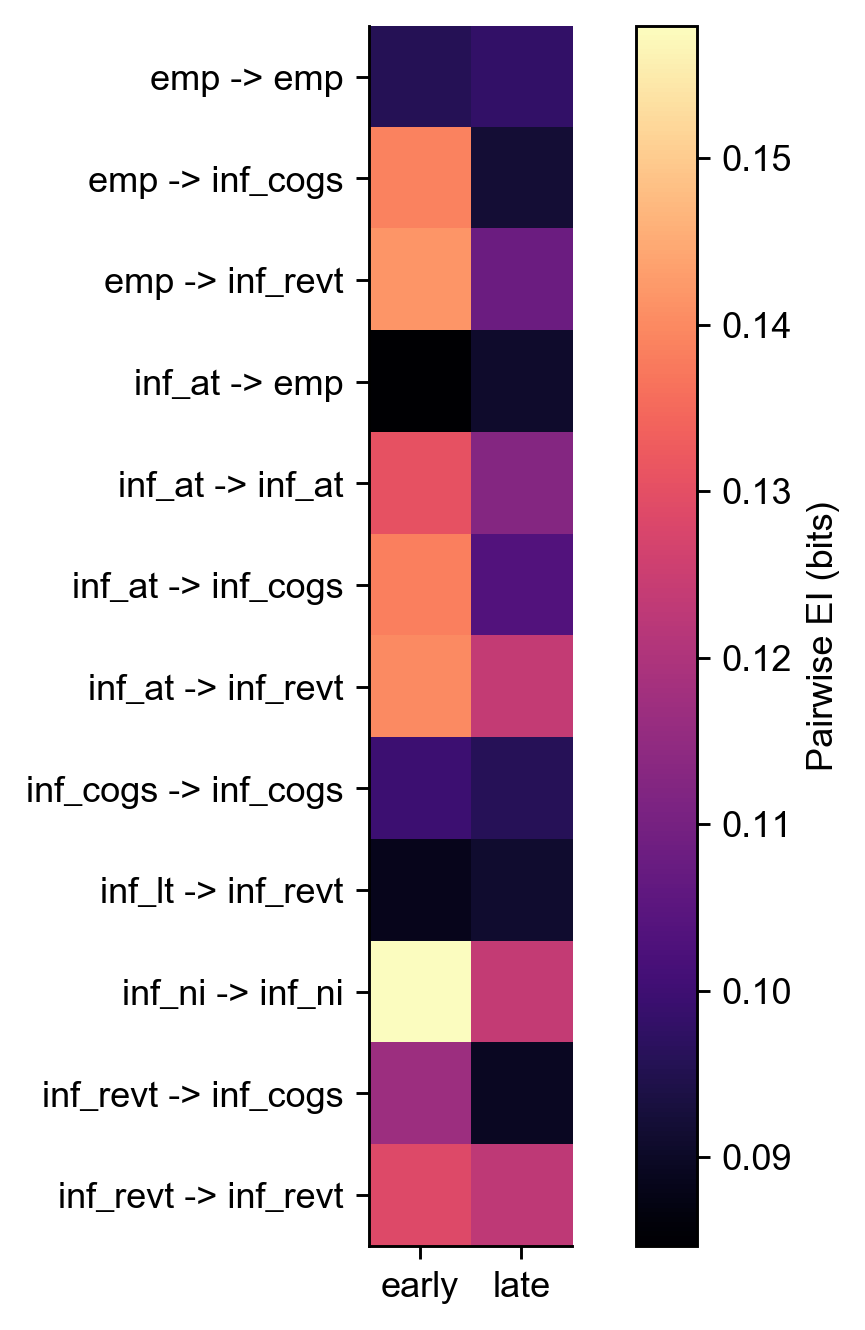

In [9]:
stability_fig = FIGURE_DIR / "peid_period_stability_heatmap.png"
if stability_fig.exists():
    display(Image(filename=str(stability_fig)))
else:
    print("当前参数设置未生成时期稳定性图。")

## 10. 参数敏感性与鲁棒性检验

`RUN_SENSITIVITY=True` 时，本节以当前 `config` 为 baseline，逐一改变可能影响结果的参数。默认重点检查 `BINS=(3,4,5,6)`，并同时扫描 `MIN_SOURCE_COUNT`、`ALPHA`、`WINSOR_*` 和年份窗口。鲁棒性结果优先以参数条件下的因果热图矩阵呈现：每个 panel 是一个参数设置下重新估计出的全量 pairwise EI 或 Top 协同矩阵，用统一色标直接比较主结构是否变化；节点图仅作为补充摘要。


In [10]:
sensitivity_config = SensitivityConfig(
    base_config=config,
    output_root=str(PROJECT_ROOT / "results" / "company_ce" / "csv" / "peid_sensitivity"),
    figure_dir=str(PROJECT_ROOT / "fig" / "company_ce" / "peid_sensitivity"),
    bins_values=SENSITIVITY_BINS_VALUES,
    min_source_count_values=SENSITIVITY_MIN_SOURCE_COUNT_VALUES,
    alpha_values=SENSITIVITY_ALPHA_VALUES,
    winsor_pairs=SENSITIVITY_WINSOR_PAIRS,
    year_windows=SENSITIVITY_YEAR_WINDOWS,
    top_m=TOP_K,
)

if RUN_SENSITIVITY:
    sensitivity_result = run_sensitivity_analysis(sensitivity_config, reuse_cache=True, skip_run_figures=True)
    configure_robustness_graph_style()
    plot_pairwise_heatmap_grid(Path(sensitivity_config.output_root), Path(sensitivity_config.figure_dir))
    plot_synergy_heatmap_grid(Path(sensitivity_config.output_root), Path(sensitivity_config.figure_dir), TOP_K)
    plot_pairwise_grid(Path(sensitivity_config.output_root), Path(sensitivity_config.figure_dir), TOP_K)
    plot_synergy_grid(Path(sensitivity_config.output_root), Path(sensitivity_config.figure_dir), TOP_K)
else:
    sensitivity_result = {"skipped": "RUN_SENSITIVITY=False"}

sensitivity_result


{'skipped': 'RUN_SENSITIVITY=False'}

In [11]:
robustness_pairwise_fig = Path(sensitivity_config.figure_dir) / "peid_robustness_pairwise_heatmap_grid.png"
robustness_synergy_fig = Path(sensitivity_config.figure_dir) / "peid_robustness_synergy_heatmap_grid.png"
supplement_pairwise_fig = Path(sensitivity_config.figure_dir) / "peid_robustness_pairwise_graph_grid.png"
supplement_synergy_fig = Path(sensitivity_config.figure_dir) / "peid_robustness_synergy_hypergraph_grid.png"
if robustness_pairwise_fig.exists() and robustness_synergy_fig.exists():
    display(Image(filename=str(robustness_pairwise_fig)))
    display(Image(filename=str(robustness_synergy_fig)))
    if supplement_pairwise_fig.exists() and supplement_synergy_fig.exists():
        print("补充节点图如下；主判断以上方热图矩阵为准。")
        display(Image(filename=str(supplement_pairwise_fig)))
        display(Image(filename=str(supplement_synergy_fig)))
else:
    print("尚未生成图形化鲁棒性结果；将 RUN_SENSITIVITY 设为 True 后运行本节，或先运行 plot_peid_robustness_graphs.py。")


尚未生成图形化鲁棒性结果；将 RUN_SENSITIVITY 设为 True 后运行本节，或先运行 plot_peid_robustness_graphs.py。


## 11. 手动调参说明

推荐调参顺序：

1. 先使用 `SMOKE` 或 3 个变量检查流水线。
2. 首先查看原生结果：全量 pairwise 边、全量 synergy 超边和 `synergy_raw`，不先做 Top-K 解读。
3. 将 `NULL_REPS` 提高到 100 或更多，用于形成最终 p 值证据。
4. 运行 `RUN_SENSITIVITY=True`，优先查看不同参数下的 pairwise EI 热图矩阵和 PEID 协同热图矩阵，而不是先读统计摘要表。
5. 继续检查 `MIN_SOURCE_COUNT`、`ALPHA`、`WINSOR_*` 和年份窗口；只有在图形化鲁棒性检验中稳定出现的边族才进入论文主结论。
